# Notebook 02 — Feature Engineering and Modeling
**Level:** 2 (mandatory)  
**Depends on:** `01_data_understanding.ipynb` (must have run preprocessing pipeline)  

---

## Objectives
1. Load the cleaned dataset.
2. Engineer temporal and operational features.
3. Create a strict temporal split (train / val / test).
4. Train multiple models.
5. Evaluate and compare on validation set.
6. Select and persist the best model.
7. Run final evaluation on the held-out test set.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))           

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.config import CFG
from src.feature_engineering import run_feature_engineering_pipeline
from src.train import (
    train_all_models,
    save_model,
    log_to_mlflow,
    extract_model_params,
    append_experiment_log,
    save_selected_model_metadata,
 )
from src.evaluate import (
    compute_metrics,
    residuals_dataframe,
    build_metrics_table,
    save_metrics_table,
    error_by_time_block,
 )

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
FIGURES_PATH = Path(CFG['paths']['reports_figures'])
TARGET = CFG['target']
print(f'Target: {TARGET}')

Target: % Silica Concentrate


---
## 1. Load Cleaned Data

In [2]:
interim_path = Path(CFG['paths']['data_interim']) / 'data_cleaned.parquet'

if not interim_path.exists():
    raise FileNotFoundError(
        'Cleaned data not found. Run notebook 01 first to generate data_cleaned.parquet.'
    )

df_clean = pd.read_parquet(interim_path)
print(f'Loaded cleaned data: {df_clean.shape}')
print(f'Date range: {df_clean.index.min()} → {df_clean.index.max()}')

Loaded cleaned data: (4097, 23)
Date range: 2017-03-10 01:00:00 → 2017-09-09 23:00:00


---
## 2. Feature Engineering

### Leakage Prevention Strategy

- Delayed lab measurements (`% Iron Concentrate`, `% Silica Concentrate`) are excluded as current predictors.
- Lag features use `shift(n)` with `n >= 1` (past-only).
- Rolling statistics are computed on `shift(1)` to exclude current observation.
- Temporal split is strict train/validation/test in chronological order.

### Feature availability assumptions

| Variable group | Examples | Availability at inference time | Decision in this notebook |
|---|---|---|---|
| Delayed lab measurements | `% Iron Concentrate`, `% Silica Concentrate` | No | Excluded as current predictors |
| Feed composition | `% Iron Feed`, `% Silica Feed` | Assumption-dependent | Main scenario includes them; sensitivity excludes them |
| Online process sensors | `Starch Flow`, `Amina Flow`, `Ore Pulp pH`, flotation columns | Yes (assumed) | Included |

### Sensitivity scenarios (anti-leakage robustness)

We train and compare four feature-availability scenarios on the same temporal split:
1. Feed ON + Target lags ON
2. Feed ON + Target lags OFF
3. Feed OFF + Target lags ON
4. Feed OFF + Target lags OFF

This shows whether model performance depends on assumptions that may not hold online.

### Target lag availability and prediction horizon

- **Prediction horizon assumed in this notebook:** one prediction is made at each modeling timestamp using only information that would already exist before that inference timestamp.
- **Current target is never used as a predictor:** `% Silica Concentrate` at time $t$ is not fed back into the model for the same row.
- **Lag construction is past-only:** target lag features are created with `shift(1)` or higher, so they refer to previously observed laboratory results.
- **Operational validity depends on real laboratory delay:** in production, the plant must confirm whether the latest lab result is already available when the prediction is requested.
- **Interpretation rule:** lagged lab inputs are operationally acceptable when they correspond to the last laboratory result already available at inference time; they would only be leakage if they used the contemporaneous target or a future / not-yet-available value.

In [3]:
# Build scenario datasets for feature-availability sensitivity

scenario_defs = [

    {"scenario": "Feed ON + TargetLags ON",  "include_feed": True,  "include_target_lags": True},

    {"scenario": "Feed ON + TargetLags OFF", "include_feed": True,  "include_target_lags": False},

    {"scenario": "Feed OFF + TargetLags ON", "include_feed": False, "include_target_lags": True},

    {"scenario": "Feed OFF + TargetLags OFF","include_feed": False, "include_target_lags": False},

]



scenario_data = {}

for sc in scenario_defs:

    X_train_sc, X_val_sc, X_test_sc, y_train_sc, y_val_sc, y_test_sc = run_feature_engineering_pipeline(

        df_clean,

        cfg=CFG,

        save=False,

        include_target_lags=sc['include_target_lags'],

        include_feed_features=sc['include_feed'],

    )

    scenario_data[sc['scenario']] = {

        'X_train': X_train_sc,

        'X_val': X_val_sc,

        'X_test': X_test_sc,

        'y_train': y_train_sc,

        'y_val': y_val_sc,

        'y_test': y_test_sc,

    }



# Keep default/main scenario for downstream compatibility

main_scenario = "Feed ON + TargetLags ON"

X_train = scenario_data[main_scenario]['X_train']

X_val   = scenario_data[main_scenario]['X_val']

X_test  = scenario_data[main_scenario]['X_test']

y_train = scenario_data[main_scenario]['y_train']

y_val   = scenario_data[main_scenario]['y_val']

y_test  = scenario_data[main_scenario]['y_test']



print(f"Main scenario: {main_scenario}")

print(f"X_train shape: {X_train.shape}")

print(f"X_val   shape: {X_val.shape}")

print(f"X_test  shape: {X_test.shape}")


[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
Main scenario: Feed ON + TargetLags ON
X

---
## 3. Baseline Reference

We load the baseline metrics saved in notebook 01 as our performance floor.

In [4]:
metrics_path = Path(CFG['paths']['reports_metrics'])
with open(metrics_path / 'baseline_metrics.json', 'r') as f:
    baseline_metrics = json.load(f)

print('Baseline metrics (predict training mean):')
for split_name, m in baseline_metrics.items():
    print(f'  {split_name}: {m}')

Baseline metrics (predict training mean):
  Train: {'MAE': 0.923, 'RMSE': 1.1254, 'R2': 0.0}
  Val: {'MAE': 0.79, 'RMSE': 1.033, 'R2': -0.0023}
  Test: {'MAE': 0.9916, 'RMSE': 1.2011, 'R2': -0.0083}


---
## 4. Model Training

### Extra Trees benchmark

Se incluye **Extra Trees Regressor** como benchmark no lineal adicional de tipo ensemble para contrastar estabilidad frente a Random Forest.

Configuración conservadora para reducir overfitting: `n_estimators=300`, `min_samples_leaf=5`, `random_state=42`, `n_jobs=-1`.

In [5]:
# Train all models for each availability scenario (validation-only model selection)

scenario_training = {}

scenario_val_tables = {}



for scenario_name, data_sc in scenario_data.items():

    print(f"\n=== Training scenario: {scenario_name} ===")

    fitted_sc, metrics_sc = train_all_models(

        data_sc['X_train'], data_sc['y_train'], data_sc['X_val'], data_sc['y_val'], cfg=CFG

    )

    scenario_training[scenario_name] = {

        'fitted_models': fitted_sc,

        'all_metrics': metrics_sc,

    }



    val_results_sc = {name: m['val'] for name, m in metrics_sc.items()}

    table_sc = build_metrics_table(val_results_sc)

    table_sc.insert(0, 'Scenario', scenario_name)

    scenario_val_tables[scenario_name] = table_sc



# Keep main scenario variables for downstream compatibility

fitted_models = scenario_training[main_scenario]['fitted_models']

all_metrics = scenario_training[main_scenario]['all_metrics']



=== Training scenario: Feed ON + TargetLags ON ===

[train] Fitting: Baseline (Mean)
[train] Baseline (Mean) | train: {'MAE': 0.9241, 'RMSE': np.float64(1.1265), 'R2': 0.0} | val: {'MAE': 0.7908, 'RMSE': np.float64(1.0331), 'R2': -0.0025}

[train] Fitting: Ridge
[train] Ridge | train: {'MAE': 0.4789, 'RMSE': np.float64(0.6802), 'R2': 0.6354} | val: {'MAE': 0.5383, 'RMSE': np.float64(0.7282), 'R2': 0.502}

[train] Fitting: Random Forest
[train] Random Forest | train: {'MAE': 0.3468, 'RMSE': np.float64(0.5103), 'R2': 0.7948} | val: {'MAE': 0.4856, 'RMSE': np.float64(0.6626), 'R2': 0.5876}

[train] Fitting: Extra Trees Regressor
[train] Extra Trees Regressor | train: {'MAE': 0.1963, 'RMSE': np.float64(0.3161), 'R2': 0.9213} | val: {'MAE': 0.4818, 'RMSE': np.float64(0.6629), 'R2': 0.5873}

[train] Fitting: XGBoost
[train] XGBoost | train: {'MAE': 0.0306, 'RMSE': np.float64(0.0405), 'R2': 0.9987} | val: {'MAE': 0.6427, 'RMSE': np.float64(0.8075), 'R2': 0.3875}

[train] Fitting: LightGBM
[t

In [ ]:
# Build validation comparison tables and define the three final model roles

scenario_lookup = pd.DataFrame(scenario_defs).rename(columns={'scenario': 'Scenario'})

val_results = {name: metrics['val'] for name, metrics in all_metrics.items()}
metrics_table = build_metrics_table(val_results)

print('\n=== Validation Metrics (Main Scenario) ===')
display(metrics_table)

sensitivity_table = pd.concat(scenario_val_tables.values(), ignore_index=True)
sensitivity_table = sensitivity_table.merge(
    scenario_lookup[['Scenario', 'include_feed', 'include_target_lags']],
    on='Scenario',
    how='left',
)

baseline_val = baseline_metrics['Val']
sensitivity_table['MAE improvement vs baseline (%)'] = (
    (baseline_val['MAE'] - sensitivity_table['MAE']) / baseline_val['MAE'] * 100
).round(2)
sensitivity_table['RMSE improvement vs baseline (%)'] = (
    (baseline_val['RMSE'] - sensitivity_table['RMSE']) / baseline_val['RMSE'] * 100
).round(2)

risk_conditions = [
    sensitivity_table['include_target_lags'],
    ~sensitivity_table['include_target_lags'] & sensitivity_table['include_feed'],
]
risk_labels = [
    'Conditional — valid if the latest lab result is already available before inference',
    'Lower — no lagged lab input, but feed availability must hold online',
]
sensitivity_table['Operational Leakage Risk'] = np.select(
    risk_conditions,
    risk_labels,
    default='Lower — no lagged lab input and process variables only',
)
sensitivity_table['risk_rank'] = np.select(
    risk_conditions,
    [1, 0],
    default=0,
 )

best_statistical_selection = sensitivity_table.sort_values(['RMSE', 'MAE'], ascending=[True, True]).iloc[0].copy().to_dict()

lagged_lab_candidates = sensitivity_table[sensitivity_table['include_target_lags'] == True].copy()
if len(lagged_lab_candidates) == 0:
    lagged_lab_candidates = sensitivity_table.copy()
    lagged_lab_selection_rule = (
        'No target-lag candidate was available, so the lagged-lab recommendation falls back to the global validation winner.'
    )
else:
    lagged_lab_selection_rule = (
        'Recommendation assumes the latest laboratory result is already available at inference time and therefore past target lags are operationally admissible.'
    )
recommended_model_with_lagged_lab_assumption = lagged_lab_candidates.sort_values(
    ['RMSE', 'MAE'],
    ascending=[True, True],
).iloc[0].copy().to_dict()

strict_no_lab_candidates = sensitivity_table[sensitivity_table['include_target_lags'] == False].copy()
if len(strict_no_lab_candidates) == 0:
    strict_no_lab_candidates = sensitivity_table.copy()
    strict_no_lab_selection_rule = (
        'No TargetLags OFF scenario was available, so the strict fallback falls back to the global validation winner.'
    )
else:
    strict_no_lab_selection_rule = (
        'Strict fallback selected among candidates that do not use lagged laboratory quality inputs.'
    )
strict_no_lab_input_fallback = strict_no_lab_candidates.sort_values(
    ['RMSE', 'MAE', 'risk_rank'],
    ascending=[True, True, True],
).iloc[0].copy().to_dict()

best_statistical_note = (
    'Best validation RMSE overall. This role is purely statistical and does not by itself decide whether lagged lab inputs are operationally acceptable.'
)

recommended_lagged_lab_note = (
    'Recommended primary model under the explicit assumption that the latest laboratory result is already available before inference. Only past target lags (`shift(1)` or greater) are used; no contemporaneous target is used as predictor.'
)

strict_no_lab_fallback_note = (
    'Conservative fallback without lagged laboratory quality inputs. If this option shows weak test performance, it indicates that sensor/process variables alone are not capturing enough target variability.'
)

best_pair = (best_statistical_selection['Scenario'], best_statistical_selection['Model'])
lagged_lab_pair = (
    recommended_model_with_lagged_lab_assumption['Scenario'],
    recommended_model_with_lagged_lab_assumption['Model'],
)
strict_no_lab_pair = (
    strict_no_lab_input_fallback['Scenario'],
    strict_no_lab_input_fallback['Model'],
)

def final_decision_label(row):
    pair = (row['Scenario'], row['Model'])
    labels = []
    if pair == best_pair:
        labels.append('Best statistical model')
    if pair == lagged_lab_pair:
        labels.append('Recommended under lagged-lab availability')
    if pair == strict_no_lab_pair:
        labels.append('Strict no-lab-input fallback')
    if not labels:
        labels.append('Alternative benchmark')
    return ' + '.join(labels)

sensitivity_table['Final Decision'] = sensitivity_table.apply(final_decision_label, axis=1)

performance_risk_table = sensitivity_table[[
    'Scenario',
    'Model',
    'MAE',
    'RMSE',
    'R2',
    'RMSE improvement vs baseline (%)',
    'include_feed',
    'include_target_lags',
    'Operational Leakage Risk',
    'Final Decision',
]].rename(columns={
    'include_feed': 'Uses feed variables',
    'include_target_lags': 'Uses target lags',
})

print('\n=== Scenario Sensitivity (Validation) ===')
display(sensitivity_table)

print('\n=== Performance vs Operational Leakage Risk ===')
display(performance_risk_table)

print('\nBest statistical model (validation RMSE):')
print(
    f"  Scenario={best_statistical_selection['Scenario']} | Model={best_statistical_selection['Model']} | RMSE={best_statistical_selection['RMSE']}"
 )
print(f"  Note: {best_statistical_note}")

print('\nRecommended model with lagged-lab availability assumption:')
print(
    f"  Scenario={recommended_model_with_lagged_lab_assumption['Scenario']} | Model={recommended_model_with_lagged_lab_assumption['Model']} | RMSE={recommended_model_with_lagged_lab_assumption['RMSE']}"
 )
print(f"  Rule: {lagged_lab_selection_rule}")
print(f"  Note: {recommended_lagged_lab_note}")

print('\nStrict no-lab-input fallback:')
print(
    f"  Scenario={strict_no_lab_input_fallback['Scenario']} | Model={strict_no_lab_input_fallback['Model']} | RMSE={strict_no_lab_input_fallback['RMSE']}"
 )
print(f"  Rule: {strict_no_lab_selection_rule}")
print(f"  Note: {strict_no_lab_fallback_note}")

# Keep the principal recommendation (lagged-lab assumption) for downstream validation plots
selected_scenario = recommended_model_with_lagged_lab_assumption['Scenario']
best_name = recommended_model_with_lagged_lab_assumption['Model']
selected_metrics_all = scenario_training[selected_scenario]['all_metrics']

# Overfitting diagnostics on the principal recommended scenario
overfit_rows = []
for model_name, mm in selected_metrics_all.items():
    tr = mm['train']
    vv = mm['val']
    overfit_rows.append({
        'Model': model_name,
        'Train_R2': tr.get('R2', np.nan),
        'Val_R2': vv.get('R2', np.nan),
        'R2_gap_train_minus_val': round(tr.get('R2', np.nan) - vv.get('R2', np.nan), 4),
        'Train_RMSE': tr.get('RMSE', np.nan),
        'Val_RMSE': vv.get('RMSE', np.nan),
        'RMSE_ratio_val_over_train': round(vv.get('RMSE', np.nan) / tr.get('RMSE', np.nan), 4) if tr.get('RMSE', 0) else np.nan,
    })

overfit_table = pd.DataFrame(overfit_rows).sort_values('Val_R2', ascending=False)
print('\n=== Overfitting diagnostics (principal recommended scenario) ===')
display(overfit_table)


=== Validation Metrics (Main Scenario) ===


,Model,MAE,RMSE,R2
0,Random Forest,0.4856,0.6626,0.5876
1,Extra Trees Regressor,0.4818,0.6629,0.5873
2,Ridge,0.5383,0.7282,0.5020
3,LightGBM,0.5752,0.7470,0.4758
4,XGBoost,0.6427,0.8075,0.3875
5,Baseline (Mean),0.7908,1.0331,-0.0025



=== Scenario Sensitivity (Validation) ===


,Scenario,Model,MAE,RMSE,R2,include_feed,include_target_lags,MAE improvement vs baseline (%),RMSE improvement vs baseline (%),Operational Leakage Risk,risk_rank,Final Decision
0,Feed ON + TargetLags ON,Random Forest,0.4856,0.6626,0.5876,True,True,38.53,35.86,High — target lags depend on delayed lab avail...,2,Best statistical benchmark
1,Feed ON + TargetLags ON,Extra Trees Regressor,0.4818,0.6629,0.5873,True,True,39.01,35.83,High — target lags depend on delayed lab avail...,2,Validation benchmark only (optimistic target-l...
2,Feed ON + TargetLags ON,Ridge,0.5383,0.7282,0.5020,True,True,31.86,29.51,High — target lags depend on delayed lab avail...,2,Validation benchmark only (optimistic target-l...
3,Feed ON + TargetLags ON,LightGBM,0.5752,0.7470,0.4758,True,True,27.19,27.69,High — target lags depend on delayed lab avail...,2,Validation benchmark only (optimistic target-l...
4,Feed ON + TargetLags ON,XGBoost,0.6427,0.8075,0.3875,True,True,18.65,21.83,High — target lags depend on delayed lab avail...,2,Validation benchmark only (optimistic target-l...
5,Feed ON + TargetLags ON,Baseline (Mean),0.7908,1.0331,-0.0025,True,True,-0.10,-0.01,High — target lags depend on delayed lab avail...,2,Validation benchmark only (optimistic target-l...
6,Feed ON + TargetLags OFF,Random Forest,0.7709,1.0006,0.0595,True,False,2.42,3.14,"Medium — no target lags, but feed availability...",1,Recommended operational model
7,Feed ON + TargetLags OFF,Baseline (Mean),0.7908,1.0331,-0.0025,True,False,-0.10,-0.01,"Medium — no target lags, but feed availability...",1,Alternative operational candidate
8,Feed ON + TargetLags OFF,Extra Trees Regressor,0.8096,1.0423,-0.0205,True,False,-2.48,-0.90,"Medium — no target lags, but feed availability...",1,Alternative operational candidate
9,Feed ON + TargetLags OFF,LightGBM,0.8293,1.0713,-0.0779,True,False,-4.97,-3.71,"Medium — no target lags, but feed availability...",1,Alternative operational candidate



=== Performance vs Operational Leakage Risk ===


,Scenario,Model,MAE,RMSE,R2,RMSE improvement vs baseline (%),Uses feed variables,Uses target lags,Operational Leakage Risk,Final Decision
0,Feed ON + TargetLags ON,Random Forest,0.4856,0.6626,0.5876,35.86,True,True,High — target lags depend on delayed lab avail...,Best statistical benchmark
1,Feed ON + TargetLags ON,Extra Trees Regressor,0.4818,0.6629,0.5873,35.83,True,True,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
2,Feed ON + TargetLags ON,Ridge,0.5383,0.7282,0.5020,29.51,True,True,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
3,Feed ON + TargetLags ON,LightGBM,0.5752,0.7470,0.4758,27.69,True,True,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
4,Feed ON + TargetLags ON,XGBoost,0.6427,0.8075,0.3875,21.83,True,True,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
5,Feed ON + TargetLags ON,Baseline (Mean),0.7908,1.0331,-0.0025,-0.01,True,True,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
6,Feed ON + TargetLags OFF,Random Forest,0.7709,1.0006,0.0595,3.14,True,False,"Medium — no target lags, but feed availability...",Recommended operational model
7,Feed ON + TargetLags OFF,Baseline (Mean),0.7908,1.0331,-0.0025,-0.01,True,False,"Medium — no target lags, but feed availability...",Alternative operational candidate
8,Feed ON + TargetLags OFF,Extra Trees Regressor,0.8096,1.0423,-0.0205,-0.90,True,False,"Medium — no target lags, but feed availability...",Alternative operational candidate
9,Feed ON + TargetLags OFF,LightGBM,0.8293,1.0713,-0.0779,-3.71,True,False,"Medium — no target lags, but feed availability...",Alternative operational candidate



Best statistical model (validation RMSE):
  Scenario=Feed ON + TargetLags ON | Model=Random Forest | RMSE=0.6626
  Note: Best statistical model uses target lags, so it should be treated as an optimistic benchmark unless delayed lab results are available with enough anticipation.

Recommended operational model:
  Scenario=Feed ON + TargetLags OFF | Model=Random Forest | RMSE=1.0006
  Rule: Recommended operational model selected only among validation candidates with TargetLags OFF.
  Note: Recommended operational model avoids target lags and assumes feed variables are available at inference time.

=== Overfitting diagnostics (selected statistical scenario) ===


,Model,Train_R2,Val_R2,R2_gap_train_minus_val,Train_RMSE,Val_RMSE,RMSE_ratio_val_over_train
2,Random Forest,0.7948,0.5876,0.2072,0.5103,0.6626,1.2985
3,Extra Trees Regressor,0.9213,0.5873,0.3340,0.3161,0.6629,2.0971
1,Ridge,0.6354,0.5020,0.1334,0.6802,0.7282,1.0706
5,LightGBM,0.9998,0.4758,0.5240,0.0178,0.7470,41.9663
4,XGBoost,0.9987,0.3875,0.6112,0.0405,0.8075,19.9383
0,Baseline (Mean),0.0000,-0.0025,0.0025,1.1265,1.0331,0.9171


---
## 5. Model Evaluation Beyond a Single Metric

We analyse: real vs predicted, residuals, temporal error patterns, and block comparisons.

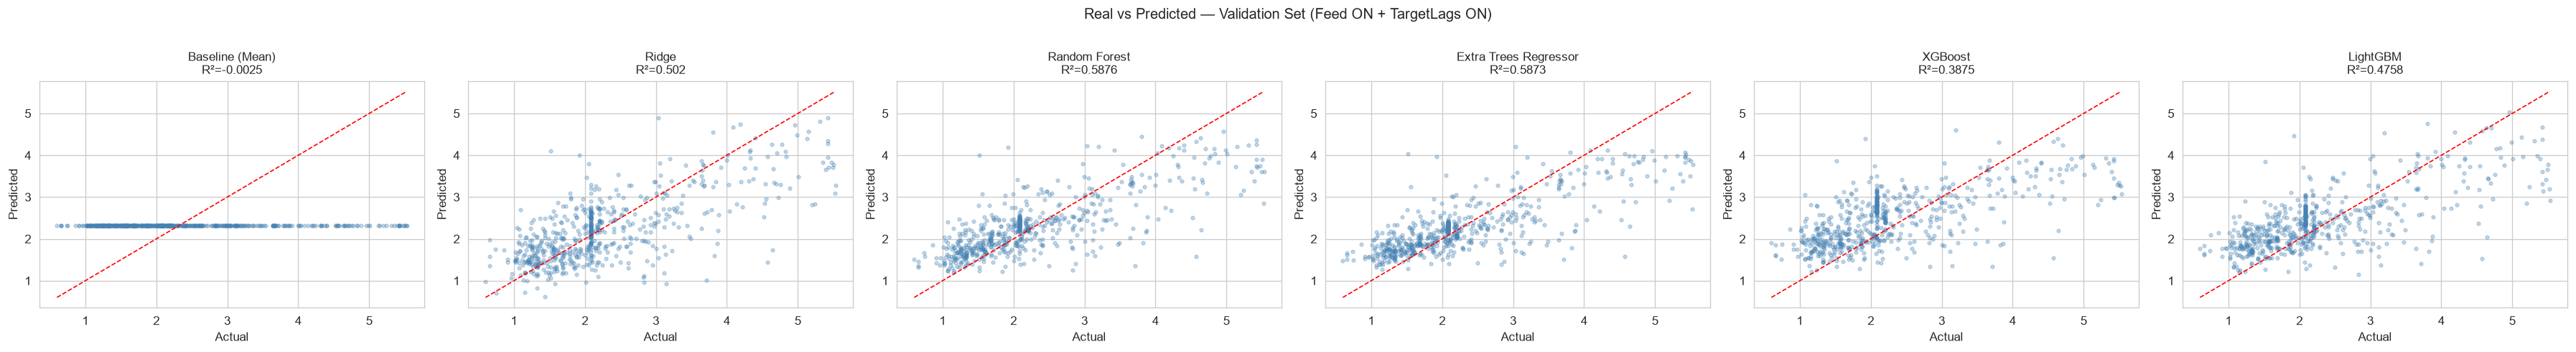

In [ ]:
# ── 5a. Real vs Predicted — principal recommended scenario on validation set ──────

selected_scenario = recommended_model_with_lagged_lab_assumption['Scenario']
selected_pack = scenario_training[selected_scenario]
fitted_models_selected = selected_pack['fitted_models']

X_val_sel = scenario_data[selected_scenario]['X_val']
y_val_sel = scenario_data[selected_scenario]['y_val']

n_models = len(fitted_models_selected)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, fitted_models_selected.items()):
    y_pred = model.predict(X_val_sel)
    ax.scatter(y_val_sel, y_pred, alpha=0.3, s=8, color='steelblue')
    lims = [min(y_val_sel.min(), y_pred.min()), max(y_val_sel.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1, label='Perfect')
    r2 = compute_metrics(y_val_sel, y_pred)['R2']
    ax.set_title(f'{name}\nR²={r2}', fontsize=10)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.suptitle(
    f'Real vs Predicted — Validation Set ({selected_scenario})',
    y=1.01,
    fontsize=12,
 )
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'real_vs_predicted_val.png', dpi=150, bbox_inches='tight')
plt.show()

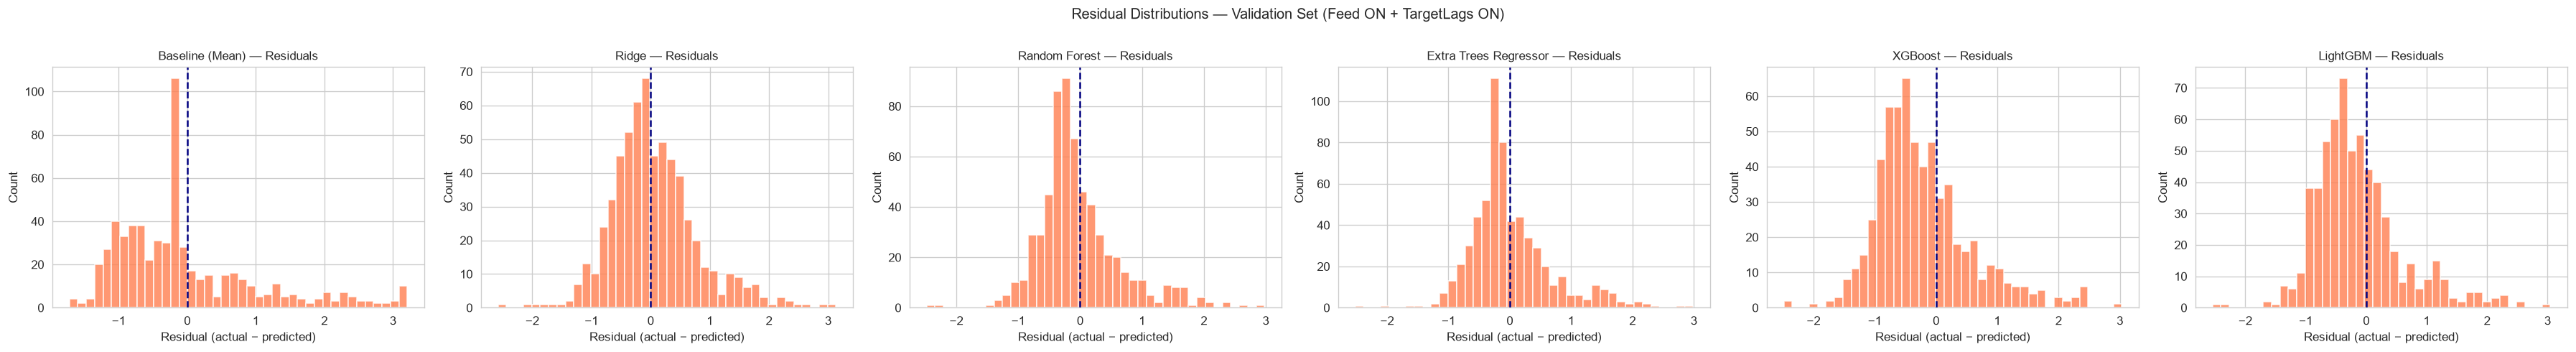

In [8]:
# ── 5b. Residuals distribution — selected scenario ──────────────────────────

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:

    axes = [axes]



for ax, (name, model) in zip(axes, fitted_models_selected.items()):

    y_pred = model.predict(X_val_sel)

    res = y_val_sel.values - y_pred

    ax.hist(res, bins=40, color='coral', edgecolor='white', alpha=0.8)

    ax.axvline(0, color='navy', lw=1.5, linestyle='--')

    ax.set_title(f'{name} — Residuals', fontsize=10)

    ax.set_xlabel('Residual (actual − predicted)')

    ax.set_ylabel('Count')



plt.suptitle(f'Residual Distributions — Validation Set ({selected_scenario})', y=1.01, fontsize=12)

plt.tight_layout()

plt.savefig(FIGURES_PATH / 'residuals_distribution.png', dpi=150, bbox_inches='tight')

plt.show()


Selected scenario (validation): Feed ON + TargetLags ON
Selected model by validation RMSE: Random Forest


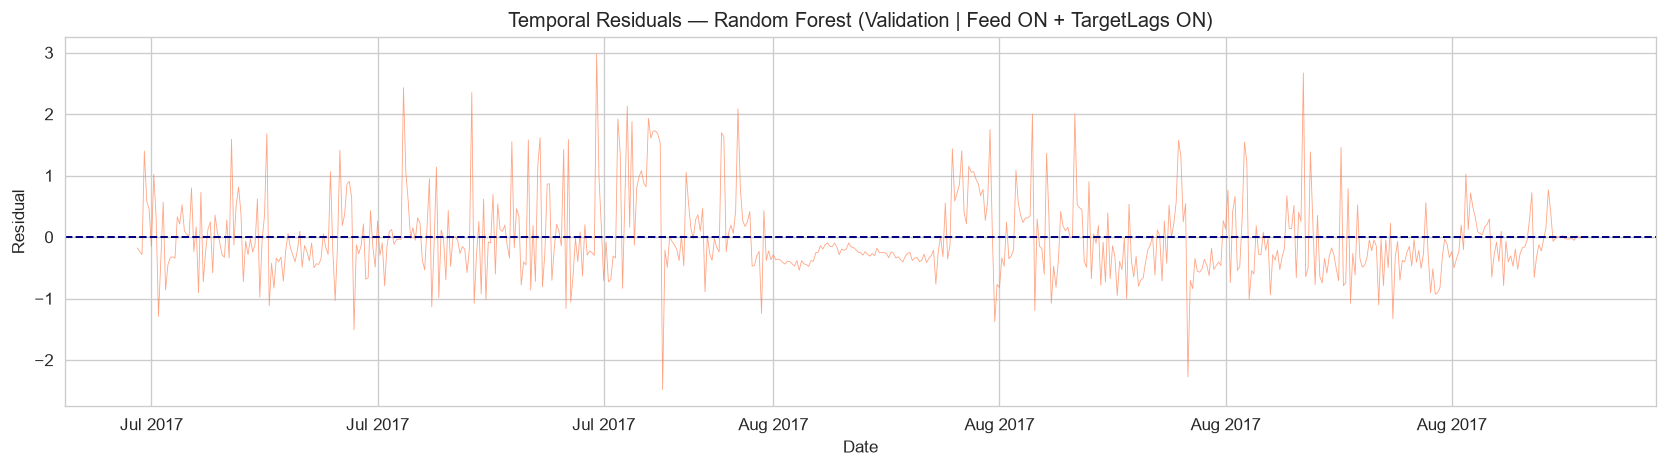

In [ ]:
# ── 5c. Temporal residual error — primary recommended model on validation ──────

best_name = recommended_model_with_lagged_lab_assumption['Model']
best_model = fitted_models_selected[best_name]

print(f"Selected scenario (validation): {selected_scenario}")
print(f"Primary recommendation under lagged-lab availability: {best_name}")

y_pred_best = best_model.predict(X_val_sel)
res_df = residuals_dataframe(y_val_sel, y_pred_best, split_name='val')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(res_df.index, res_df['residual'], lw=0.5, color='coral', alpha=0.7)
ax.axhline(0, color='navy', lw=1.2, linestyle='--')
ax.set_title(f'Temporal Residuals — {best_name} (Validation | {selected_scenario})', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Residual')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'temporal_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

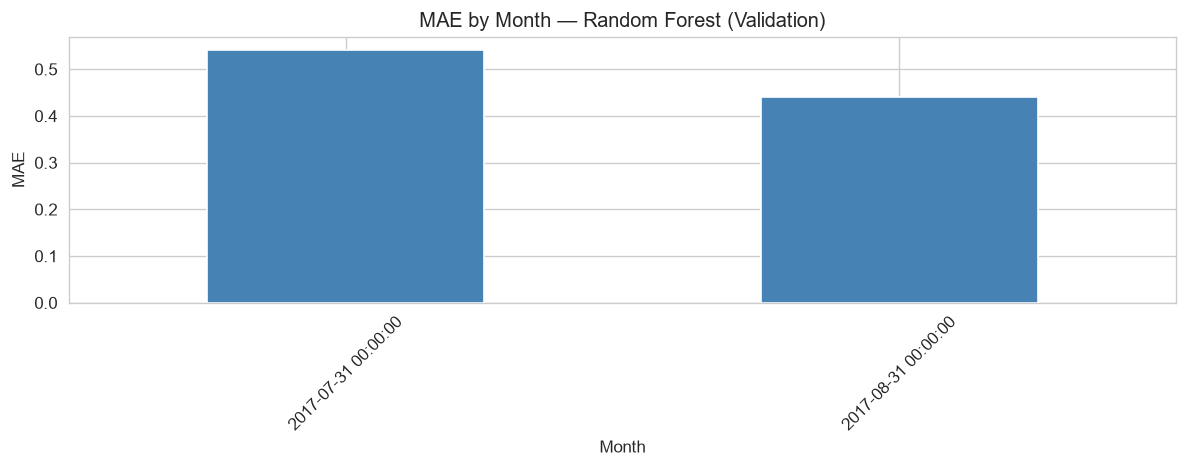

,MAE,RMSE,n_obs
date,,,
2017-07-31,0.542072,0.755722,270
2017-08-31,0.441319,0.579472,345


In [10]:
# ── 5d. Error by monthly block ────────────────────────────────────────────
monthly_error = error_by_time_block(res_df, freq='ME')

fig, ax = plt.subplots(figsize=(10, 4))
monthly_error['MAE'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'MAE by Month — {best_name} (Validation)', fontsize=12)
ax.set_ylabel('MAE')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'mae_by_month.png', dpi=150, bbox_inches='tight')
plt.show()
monthly_error

---
## 6. Model Selection and Final Test Evaluation

**Selection protocol (strict temporal validation):**
- Model selection is based on validation RMSE only.
- The test set is not used for tuning and is evaluated only after all final roles are fixed.
- We keep three final labels for reporting:
  1. **Best statistical model** = lowest validation RMSE overall.
  2. **Recommended model with lagged-lab assumption** = best candidate when the latest laboratory result is assumed to be already available at inference time.
  3. **Strict no-lab-input fallback** = best candidate with `TargetLags OFF`.

**Interpretation rule for target lags:**
- Past target lags are not treated as automatic leakage.
- They are acceptable when they represent the last laboratory result already available at inference time.
- They would only become leakage if they used the contemporaneous target or a value that would not yet be available in production.
- If the strict no-lab-input fallback performs poorly, it should be treated as a conservative backup and a signal that additional feature engineering or richer process instrumentation is needed.

In [ ]:
# Final evaluation on test set (used only after validation-based roles are fixed)

best_statistical_model = scenario_training[best_statistical_selection['Scenario']]['fitted_models'][best_statistical_selection['Model']]
model_lagged_lab_assumption = scenario_training[recommended_model_with_lagged_lab_assumption['Scenario']]['fitted_models'][recommended_model_with_lagged_lab_assumption['Model']]
model_strict_no_lab_input = scenario_training[strict_no_lab_input_fallback['Scenario']]['fitted_models'][strict_no_lab_input_fallback['Model']]

final_selection_specs = [
    {
        'selection_role': 'best_statistical_model',
        'selection_note': best_statistical_note,
        **best_statistical_selection,
    },
    {
        'selection_role': 'recommended_model_with_lagged_lab_assumption',
        'selection_note': recommended_lagged_lab_note,
        **recommended_model_with_lagged_lab_assumption,
    },
    {
        'selection_role': 'strict_no_lab_input_fallback',
        'selection_note': strict_no_lab_fallback_note,
        **strict_no_lab_input_fallback,
    },
]

final_rows = []
for spec in final_selection_specs:
    scenario_name = spec['Scenario']
    model_name = spec['Model']
    model_obj = scenario_training[scenario_name]['fitted_models'][model_name]
    X_test_candidate = scenario_data[scenario_name]['X_test']
    y_test_candidate = scenario_data[scenario_name]['y_test']
    y_pred_candidate = model_obj.predict(X_test_candidate)
    metrics_candidate = compute_metrics(y_test_candidate, y_pred_candidate)

    final_rows.append({
        'Selection role': spec['selection_role'],
        'Scenario': scenario_name,
        'Model': model_name,
        'MAE': metrics_candidate['MAE'],
        'RMSE': metrics_candidate['RMSE'],
        'R2': metrics_candidate['R2'],
        'Uses feed variables': bool(spec['include_feed']),
        'Uses target lags': bool(spec['include_target_lags']),
        'Selection note': spec['selection_note'],
    })

final_test_table = pd.DataFrame(final_rows).drop_duplicates(subset=['Selection role'])
baseline_test = baseline_metrics['Test']
final_test_table['MAE improvement vs baseline (%)'] = (
    (baseline_test['MAE'] - final_test_table['MAE']) / baseline_test['MAE'] * 100
).round(2)
final_test_table['RMSE improvement vs baseline (%)'] = (
    (baseline_test['RMSE'] - final_test_table['RMSE']) / baseline_test['RMSE'] * 100
).round(2)

print('\n=== Final Test Set Metrics (post-selection only) ===')
display(final_test_table)

print('\nBaseline Test (from nb01):')
print(f"  MAE:  {baseline_test['MAE']}")
print(f"  RMSE: {baseline_test['RMSE']}")
print(f"  R²:   {baseline_test['R2']}")

lagged_lab_scenario = recommended_model_with_lagged_lab_assumption['Scenario']
lagged_lab_model_name = recommended_model_with_lagged_lab_assumption['Model']
strict_no_lab_scenario = strict_no_lab_input_fallback['Scenario']
strict_no_lab_model_name = strict_no_lab_input_fallback['Model']

X_test_sel = scenario_data[lagged_lab_scenario]['X_test']
y_test_sel = scenario_data[lagged_lab_scenario]['y_test']
y_pred_test = model_lagged_lab_assumption.predict(X_test_sel)
lagged_lab_test_metrics = compute_metrics(y_test_sel, y_pred_test)

strict_X_test_sel = scenario_data[strict_no_lab_scenario]['X_test']
strict_y_test_sel = scenario_data[strict_no_lab_scenario]['y_test']
strict_y_pred_test = model_strict_no_lab_input.predict(strict_X_test_sel)
strict_no_lab_test_metrics = compute_metrics(strict_y_test_sel, strict_y_pred_test)

print('\n=== Key comparison requested for defendability ===')
print(
    f"Lagged-lab recommendation test R²: {lagged_lab_test_metrics['R2']} | "
    f"Strict no-lab fallback test R²: {strict_no_lab_test_metrics['R2']}"
 )


=== Final Test Set Metrics (post-selection only) ===


,Selection role,Scenario,Model,MAE,RMSE,R2,Uses feed variables,Uses target lags,Selection note,MAE improvement vs baseline (%),RMSE improvement vs baseline (%)
0,best_statistical_model,Feed ON + TargetLags ON,Random Forest,0.5500,0.7474,0.6096,True,True,"Best statistical model uses target lags, so it...",44.53,37.77
1,recommended_operational_model,Feed ON + TargetLags OFF,Random Forest,0.9306,1.1671,0.0480,True,False,Recommended operational model avoids target la...,6.15,2.83



Baseline Test (from nb01):
  MAE:  0.9916
  RMSE: 1.2011
  R²:   -0.0083


In [12]:
# Save validation/test traceability tables and compare against baseline

reports_metrics_path = Path(CFG['paths']['reports_metrics'])
validation_sensitivity_path = reports_metrics_path / 'validation_sensitivity_table.csv'
performance_risk_path = reports_metrics_path / 'performance_vs_operational_leakage_risk.csv'
final_test_metrics_path = reports_metrics_path / 'final_selected_models_test_metrics.csv'

sensitivity_table.to_csv(validation_sensitivity_path, index=False)
performance_risk_table.to_csv(performance_risk_path, index=False)
final_test_table.to_csv(final_test_metrics_path, index=False)

leaderboard_local = sensitivity_table.sort_values(['RMSE', 'MAE'], ascending=[True, True]).copy()
leaderboard_local.insert(0, 'split', 'validation')
leaderboard_local_path = reports_metrics_path / 'mlflow_leaderboard.csv'
leaderboard_local.to_csv(leaderboard_local_path, index=False)

save_metrics_table(
    final_test_table.rename(columns={'Selection role': 'Model role'}),
    CFG,
)

print('\n=== Validation improvement vs baseline (%) ===')
display(
    performance_risk_table[[
        'Scenario',
        'Model',
        'RMSE improvement vs baseline (%)',
        'Operational Leakage Risk',
        'Final Decision',
    ]]
)

print('\n=== Final selected models vs baseline on test (%) ===')
display(
    final_test_table[[
        'Selection role',
        'Scenario',
        'Model',
        'MAE improvement vs baseline (%)',
        'RMSE improvement vs baseline (%)',
    ]]
)

print(f'Validation sensitivity saved to: {validation_sensitivity_path}')
print(f'Performance/risk table saved to: {performance_risk_path}')
print(f'Final test metrics saved to: {final_test_metrics_path}')
print(f'Leaderboard fallback saved to: {leaderboard_local_path}')

[evaluate] Metrics saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\model_comparison.csv

=== Validation improvement vs baseline (%) ===


,Scenario,Model,RMSE improvement vs baseline (%),Operational Leakage Risk,Final Decision
0,Feed ON + TargetLags ON,Random Forest,35.86,High — target lags depend on delayed lab avail...,Best statistical benchmark
1,Feed ON + TargetLags ON,Extra Trees Regressor,35.83,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
2,Feed ON + TargetLags ON,Ridge,29.51,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
3,Feed ON + TargetLags ON,LightGBM,27.69,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
4,Feed ON + TargetLags ON,XGBoost,21.83,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
5,Feed ON + TargetLags ON,Baseline (Mean),-0.01,High — target lags depend on delayed lab avail...,Validation benchmark only (optimistic target-l...
6,Feed ON + TargetLags OFF,Random Forest,3.14,"Medium — no target lags, but feed availability...",Recommended operational model
7,Feed ON + TargetLags OFF,Baseline (Mean),-0.01,"Medium — no target lags, but feed availability...",Alternative operational candidate
8,Feed ON + TargetLags OFF,Extra Trees Regressor,-0.90,"Medium — no target lags, but feed availability...",Alternative operational candidate
9,Feed ON + TargetLags OFF,LightGBM,-3.71,"Medium — no target lags, but feed availability...",Alternative operational candidate



=== Final selected models vs baseline on test (%) ===


,Selection role,Scenario,Model,MAE improvement vs baseline (%),RMSE improvement vs baseline (%)
0,best_statistical_model,Feed ON + TargetLags ON,Random Forest,44.53,37.77
1,recommended_operational_model,Feed ON + TargetLags OFF,Random Forest,6.15,2.83


Validation sensitivity saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\validation_sensitivity_table.csv
Performance/risk table saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\performance_vs_operational_leakage_risk.csv
Final test metrics saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\final_selected_models_test_metrics.csv
Leaderboard fallback saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\mlflow_leaderboard.csv


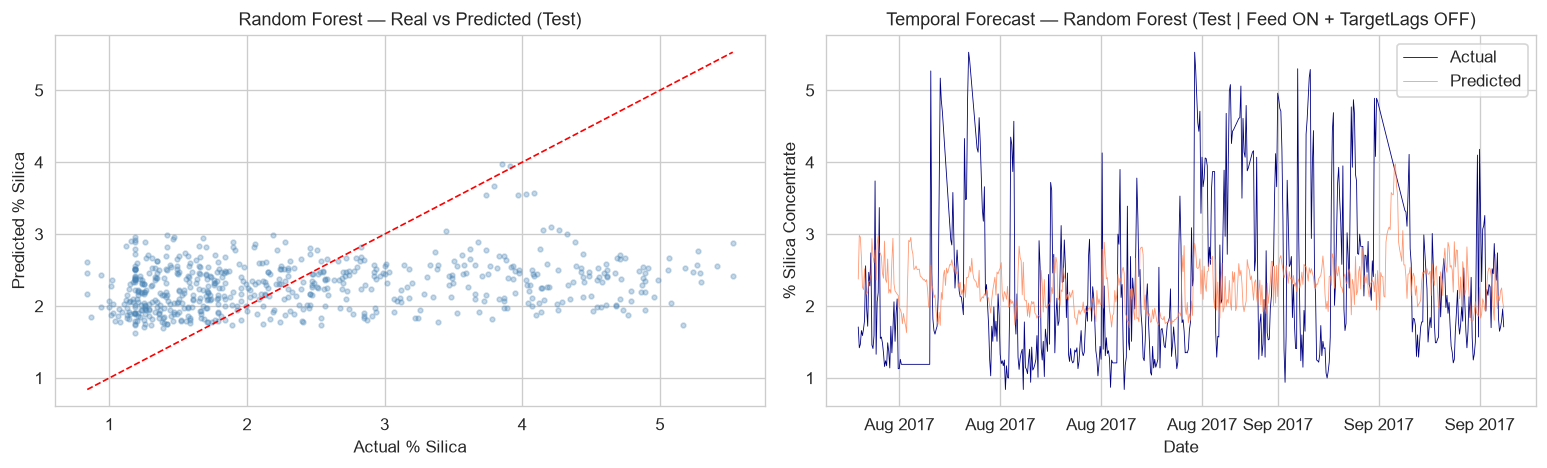

In [ ]:
# Real vs Predicted — Test set for the lagged-lab recommendation

res_df_test = residuals_dataframe(y_test_sel, y_pred_test, split_name='test')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter
axes[0].scatter(y_test_sel, y_pred_test, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test_sel.min(), y_pred_test.min()), max(y_test_sel.max(), y_pred_test.max())]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_title(f'{lagged_lab_model_name} — Real vs Predicted (Test)', fontsize=11)
axes[0].set_xlabel('Actual % Silica')
axes[0].set_ylabel('Predicted % Silica')

# Temporal prediction trace
axes[1].plot(res_df_test.index, res_df_test['y_true'], lw=0.5, label='Actual', color='navy')
axes[1].plot(res_df_test.index, res_df_test['y_pred'], lw=0.5, label='Predicted', color='coral', alpha=0.8)
axes[1].set_title(
    f'Temporal Forecast — {lagged_lab_model_name} (Test | {lagged_lab_scenario})',
    fontsize=11,
 )
axes[1].set_xlabel('Date')
axes[1].set_ylabel('% Silica Concentrate')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'real_vs_predicted_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Save Final Model Artifacts

In [ ]:
# Persist the primary lagged-lab recommendation and the strict no-lab fallback

best_statistical_test_metrics = final_test_table.loc[
    final_test_table['Selection role'] == 'best_statistical_model',
    ['MAE', 'RMSE', 'R2'],
]
best_statistical_test_metrics = best_statistical_test_metrics.iloc[0].to_dict()

model_lagged_lab_assumption_path = save_model(
    model_lagged_lab_assumption,
    model_name=lagged_lab_model_name,
    folder='selected',
    cfg=CFG,
    filename='model_lagged_lab_assumption.pkl',
)

# Optional generic alias for downstream compatibility
_ = save_model(
    model_lagged_lab_assumption,
    model_name=lagged_lab_model_name,
    folder='selected',
    cfg=CFG,
    filename='model.pkl',
)

model_strict_no_lab_input_path = save_model(
    model_strict_no_lab_input,
    model_name=strict_no_lab_model_name,
    folder='selected',
    cfg=CFG,
    filename='model_strict_no_lab_input.pkl',
)

X_train_lagged_lab = scenario_data[lagged_lab_scenario]['X_train']
feature_columns = list(X_train_lagged_lab.columns)
feature_list_path = Path(CFG['paths']['models_selected']) / 'feature_columns.json'
with open(feature_list_path, 'w', encoding='utf-8') as f:
    json.dump(feature_columns, f, indent=2, ensure_ascii=False)

strict_feature_columns = list(scenario_data[strict_no_lab_scenario]['X_train'].columns)
strict_feature_list_path = Path(CFG['paths']['models_selected']) / 'feature_columns_strict_no_lab_input.json'
with open(strict_feature_list_path, 'w', encoding='utf-8') as f:
    json.dump(strict_feature_columns, f, indent=2, ensure_ascii=False)

selected_model_metadata = {
    'selection_protocol': 'Validation RMSE only; test used only after all final roles were fixed.',
    'saved_model_role': 'recommended_model_with_lagged_lab_assumption',
    'saved_model_path': str(model_lagged_lab_assumption_path),
    'feature_columns_path': str(feature_list_path),
    'best_statistical_model': {
        'scenario': best_statistical_selection['Scenario'],
        'model_name': best_statistical_selection['Model'],
        'validation_metrics': {
            'MAE': float(best_statistical_selection['MAE']),
            'RMSE': float(best_statistical_selection['RMSE']),
            'R2': float(best_statistical_selection['R2']),
        },
        'test_metrics': best_statistical_test_metrics,
        'uses_feed_variables': bool(best_statistical_selection['include_feed']),
        'uses_target_lags': bool(best_statistical_selection['include_target_lags']),
        'note': best_statistical_note,
    },
    'recommended_model_with_lagged_lab_assumption': {
        'scenario': recommended_model_with_lagged_lab_assumption['Scenario'],
        'model_name': recommended_model_with_lagged_lab_assumption['Model'],
        'validation_metrics': {
            'MAE': float(recommended_model_with_lagged_lab_assumption['MAE']),
            'RMSE': float(recommended_model_with_lagged_lab_assumption['RMSE']),
            'R2': float(recommended_model_with_lagged_lab_assumption['R2']),
        },
        'test_metrics': lagged_lab_test_metrics,
        'uses_feed_variables': bool(recommended_model_with_lagged_lab_assumption['include_feed']),
        'uses_target_lags': bool(recommended_model_with_lagged_lab_assumption['include_target_lags']),
        'model_class': type(model_lagged_lab_assumption).__name__,
        'model_params': extract_model_params(model_lagged_lab_assumption),
        'model_path': str(model_lagged_lab_assumption_path),
        'feature_columns_path': str(feature_list_path),
        'note': recommended_lagged_lab_note,
    },
    'strict_no_lab_input_fallback': {
        'scenario': strict_no_lab_input_fallback['Scenario'],
        'model_name': strict_no_lab_input_fallback['Model'],
        'validation_metrics': {
            'MAE': float(strict_no_lab_input_fallback['MAE']),
            'RMSE': float(strict_no_lab_input_fallback['RMSE']),
            'R2': float(strict_no_lab_input_fallback['R2']),
        },
        'test_metrics': strict_no_lab_test_metrics,
        'uses_feed_variables': bool(strict_no_lab_input_fallback['include_feed']),
        'uses_target_lags': bool(strict_no_lab_input_fallback['include_target_lags']),
        'model_class': type(model_strict_no_lab_input).__name__,
        'model_params': extract_model_params(model_strict_no_lab_input),
        'model_path': str(model_strict_no_lab_input_path),
        'feature_columns_path': str(strict_feature_list_path),
        'note': strict_no_lab_fallback_note,
    },
}

print(f'Primary model saved to: {model_lagged_lab_assumption_path}')
print(f'Strict fallback saved to: {model_strict_no_lab_input_path}')
print(f'Primary feature list saved to: {feature_list_path}')
print(f'Strict fallback feature list saved to: {strict_feature_list_path}')

[train] Model saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\model.pkl
Recommended operational model saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\model.pkl
Feature list saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\feature_columns.json


In [ ]:
# Always create reproducible local fallback files (CSV/JSON), even if MLflow also works

experiment_rows = []

for _, row in sensitivity_table.iterrows():
    experiment_rows.append({
        'record_type': 'validation_candidate',
        'selection_role': row['Final Decision'],
        'scenario': row['Scenario'],
        'model_name': row['Model'],
        'split': 'validation',
        'MAE': row['MAE'],
        'RMSE': row['RMSE'],
        'R2': row['R2'],
        'MAE_improvement_vs_baseline_pct': row['MAE improvement vs baseline (%)'],
        'RMSE_improvement_vs_baseline_pct': row['RMSE improvement vs baseline (%)'],
        'uses_feed_variables': bool(row['Uses feed variables']) if 'Uses feed variables' in row.index else bool(row['include_feed']),
        'uses_target_lags': bool(row['Uses target lags']) if 'Uses target lags' in row.index else bool(row['include_target_lags']),
        'operational_leakage_risk': row['Operational Leakage Risk'],
        'model_class': type(scenario_training[row['Scenario']]['fitted_models'][row['Model']]).__name__,
        'model_params': json.dumps(extract_model_params(scenario_training[row['Scenario']]['fitted_models'][row['Model']])),
        'feature_columns_path': str(feature_list_path) if (row['Scenario'], row['Model']) == (lagged_lab_scenario, lagged_lab_model_name) else '',
        'saved_model_path': str(model_lagged_lab_assumption_path) if (row['Scenario'], row['Model']) == (lagged_lab_scenario, lagged_lab_model_name) else '',
        'artifacts': json.dumps([str(validation_sensitivity_path), str(performance_risk_path), str(leaderboard_local_path)]),
    })

for _, row in final_test_table.iterrows():
    selected_model_path = ''
    selected_feature_path = ''
    if row['Selection role'] == 'recommended_model_with_lagged_lab_assumption':
        selected_model_path = str(model_lagged_lab_assumption_path)
        selected_feature_path = str(feature_list_path)
    elif row['Selection role'] == 'strict_no_lab_input_fallback':
        selected_model_path = str(model_strict_no_lab_input_path)
        selected_feature_path = str(strict_feature_list_path)

    experiment_rows.append({
        'record_type': 'final_evaluation',
        'selection_role': row['Selection role'],
        'scenario': row['Scenario'],
        'model_name': row['Model'],
        'split': 'test',
        'MAE': row['MAE'],
        'RMSE': row['RMSE'],
        'R2': row['R2'],
        'MAE_improvement_vs_baseline_pct': row['MAE improvement vs baseline (%)'],
        'RMSE_improvement_vs_baseline_pct': row['RMSE improvement vs baseline (%)'],
        'uses_feed_variables': bool(row['Uses feed variables']),
        'uses_target_lags': bool(row['Uses target lags']),
        'operational_leakage_risk': row['Selection note'],
        'model_class': type(scenario_training[row['Scenario']]['fitted_models'][row['Model']]).__name__,
        'model_params': json.dumps(extract_model_params(scenario_training[row['Scenario']]['fitted_models'][row['Model']])),
        'feature_columns_path': selected_feature_path,
        'saved_model_path': selected_model_path,
        'artifacts': json.dumps([str(final_test_metrics_path), str(feature_list_path), str(model_lagged_lab_assumption_path), str(model_strict_no_lab_input_path)]),
    })

experiment_log_path = Path(CFG['paths']['reports_metrics']) / 'experiment_log.csv'
experiment_log_df = pd.DataFrame(experiment_rows)
experiment_log_df.to_csv(experiment_log_path, index=False)

selected_model_metadata['artifacts'] = {
    'validation_sensitivity_table': str(validation_sensitivity_path),
    'performance_vs_operational_leakage_risk': str(performance_risk_path),
    'final_selected_models_test_metrics': str(final_test_metrics_path),
    'experiment_log_csv': str(experiment_log_path),
    'leaderboard_csv': str(leaderboard_local_path),
    'figures': [
        str(FIGURES_PATH / 'real_vs_predicted_val.png'),
        str(FIGURES_PATH / 'residuals_distribution.png'),
        str(FIGURES_PATH / 'temporal_residuals.png'),
        str(FIGURES_PATH / 'mae_by_month.png'),
        str(FIGURES_PATH / 'real_vs_predicted_test.png'),
    ],
}

selected_model_metadata['reproducibility'] = {
    'include_feed_features': bool(recommended_model_with_lagged_lab_assumption['include_feed']),
    'include_target_lags': bool(recommended_model_with_lagged_lab_assumption['include_target_lags']),
    'lagged_lab_selection_rule': lagged_lab_selection_rule,
    'strict_no_lab_selection_rule': strict_no_lab_selection_rule,
}

selected_model_metadata_path = save_selected_model_metadata(selected_model_metadata, cfg=CFG)

append_experiment_log(
    {
        'record_type': 'notebook_status',
        'selection_role': 'recommended_model_with_lagged_lab_assumption',
        'scenario': lagged_lab_scenario,
        'model_name': lagged_lab_model_name,
        'split': 'metadata',
        'MAE': lagged_lab_test_metrics['MAE'],
        'RMSE': lagged_lab_test_metrics['RMSE'],
        'R2': lagged_lab_test_metrics['R2'],
        'saved_model_path': str(model_lagged_lab_assumption_path),
        'feature_columns_path': str(feature_list_path),
        'selected_model_metadata_path': str(selected_model_metadata_path),
        'artifacts': json.dumps(selected_model_metadata['artifacts']),
    },
    cfg=CFG,
)

print(f'Fallback local CSV created at: {experiment_log_path}')
print(f'Selected model metadata saved to: {selected_model_metadata_path}')

[train] Selected-model metadata saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\selected_model_metadata.json
[train] Local experiment log updated: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\experiment_log.csv
Fallback local CSV created at: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\experiment_log.csv
Selected model metadata saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\selected_model_metadata.json


---
## MLOps and Experiment Traceability

- **Experiment registration:** each final model role is logged with experiment name, scenario, model name, model parameters, validation metrics, and final test metrics once post-selection evaluation is allowed.
- **Selected model identity:** the main deployment candidate is `models/selected/model_lagged_lab_assumption.pkl`; the strict conservative backup is `models/selected/model_strict_no_lab_input.pkl`.
- **Metrics storage:** validation sensitivity, performance-vs-risk comparison, final test metrics, leaderboard, and the fallback experiment log are stored under `reports/metrics/`.
- **Model storage:** both selected model artifacts, their feature schemas, and the selection metadata are stored in `models/selected/`.
- **Reproducibility:** training can be reproduced from the saved metadata, scenario assumptions, feature lists, and parameters; inference and explainability should use the lagged-lab model unless operations reject that availability assumption.
- **Fallback rule:** if MLflow tracking fails, the notebook still leaves a complete CSV/JSON trace locally instead of reporting that tracking was skipped.

In [ ]:
# Prepare descriptive MLflow context for final model-role tracking

raw_experiment_name = CFG.get('mlflow', {}).get('experiment_name', '').strip()
legacy_names = {'', 'minsur', 'minsur-silica-prediction'}
if raw_experiment_name in legacy_names:
    experiment_name = 'MINSUR Silica Prediction - Temporal Modeling'
else:
    experiment_name = raw_experiment_name

selected_artifact_paths = [
    validation_sensitivity_path,
    performance_risk_path,
    final_test_metrics_path,
    experiment_log_path,
    selected_model_metadata_path,
    feature_list_path,
    strict_feature_list_path,
    model_lagged_lab_assumption_path,
    model_strict_no_lab_input_path,
    FIGURES_PATH / 'real_vs_predicted_test.png',
]

print(f'Experiment name prepared for tracking: {experiment_name}')
print('Final model artifacts ready for MLflow/local traceability.')

Experiment name prepared for tracking: MINSUR Silica Prediction - Temporal Modeling
Selected-model artifacts ready for MLflow/local traceability.


In [ ]:
# Track the final model roles in MLflow; keep local CSV/JSON traceability regardless of outcome

final_test_lookup = {
    row['Selection role']: {'MAE': row['MAE'], 'RMSE': row['RMSE'], 'R2': row['R2']}
    for _, row in final_test_table.iterrows()
}

mlflow_tracking_results = []
for spec in final_selection_specs:
    scenario_name = spec['Scenario']
    model_name = spec['Model']
    model_obj = scenario_training[scenario_name]['fitted_models'][model_name]
    train_metrics = scenario_training[scenario_name]['all_metrics'][model_name]['train']
    val_metrics = scenario_training[scenario_name]['all_metrics'][model_name]['val']
    run_feature_columns = list(scenario_data[scenario_name]['X_train'].columns)
    run_artifacts = [validation_sensitivity_path, performance_risk_path, final_test_metrics_path, experiment_log_path]
    run_model_path = None

    if spec['selection_role'] == 'recommended_model_with_lagged_lab_assumption':
        run_artifacts = selected_artifact_paths
        run_model_path = model_lagged_lab_assumption_path
    elif spec['selection_role'] == 'strict_no_lab_input_fallback':
        run_model_path = model_strict_no_lab_input_path

    tracking_result = log_to_mlflow(
        model=model_obj,
        model_name=model_name,
        train_metrics=train_metrics,
        val_metrics=val_metrics,
        test_metrics=final_test_lookup.get(spec['selection_role']),
        scenario_name=scenario_name,
        feature_columns=run_feature_columns,
        model_path=run_model_path,
        artifact_paths=run_artifacts,
        extra_params={
            'selection_role': spec['selection_role'],
            'include_feed_features': bool(spec['include_feed']),
            'include_target_lags': bool(spec['include_target_lags']),
            'selection_protocol': 'validation_only_then_final_test',
            'experiment_name': experiment_name,
        },
        tags={
            'selection_role': spec['selection_role'],
            'operational_leakage_risk': spec['Operational Leakage Risk'],
        },
        run_name=f"{experiment_name} | {spec['selection_role']} | {scenario_name} | {model_name}",
        cfg=CFG,
    )

    mlflow_tracking_results.append({
        'selection_role': spec['selection_role'],
        'scenario': scenario_name,
        'model_name': model_name,
        **tracking_result,
    })

mlflow_tracking_df = pd.DataFrame(mlflow_tracking_results)
selected_model_metadata['mlflow_tracking'] = mlflow_tracking_results
save_selected_model_metadata(selected_model_metadata, cfg=CFG)

print('=== MLflow / fallback tracking status ===')
display(mlflow_tracking_df)

if (mlflow_tracking_df['status'] == 'mlflow_logged').any():
    print('At least one final model role was registered in MLflow and all local fallback files were preserved.')
else:
    print('MLflow was unavailable or failed, so the notebook preserved complete local CSV/JSON traceability instead.')

2026/06/15 16:25:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 16:25:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/15 16:30:03 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\A805B~1.ALV\AppData\Local\Temp\tmpjybsbx4v\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.9.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


[train] MLflow run logged for: Random Forest


2026/06/15 16:30:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 16:30:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/15 16:32:33 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\A805B~1.ALV\AppData\Local\Temp\tmpsmhx_1vp\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.9.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


[train] MLflow run logged for: Random Forest
[train] Selected-model metadata saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\selected_model_metadata.json
=== MLflow / fallback tracking status ===


,selection_role,scenario,model_name,status,experiment_name,run_name,run_id
0,best_statistical_model,Feed ON + TargetLags ON,Random Forest,mlflow_logged,MINSUR Silica Prediction - Temporal Modeling,MINSUR Silica Prediction - Temporal Modeling |...,724f4913affa469a9a921fab8ea0540e
1,recommended_operational_model,Feed ON + TargetLags OFF,Random Forest,mlflow_logged,MINSUR Silica Prediction - Temporal Modeling,MINSUR Silica Prediction - Temporal Modeling |...,4e7e630e318c4aeab1913fdb2d6ea7cf


At least one selected model was registered in MLflow and all local fallback files were preserved.


In [18]:
# Build a leaderboard view from MLflow when available, otherwise from the local fallback CSV

leaderboard_path = Path(CFG['paths']['reports_metrics']) / 'mlflow_leaderboard.csv'
leaderboard_source = 'local_fallback'
leaderboard = pd.read_csv(leaderboard_path)

try:
    import os
    import mlflow
    from mlflow.tracking import MlflowClient

    tracking_path = Path(CFG['paths']['mlruns'])
    tracking_path.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault('MLFLOW_ALLOW_FILE_STORE', 'true')
    mlflow.set_tracking_uri(str(tracking_path))
    client = MlflowClient(tracking_uri=str(tracking_path))
    exp = client.get_experiment_by_name(experiment_name)

    if exp is not None:
        runs_df = mlflow.search_runs(
            experiment_ids=[exp.experiment_id],
            output_format='pandas',
        )
        if len(runs_df) > 0:
            keep_cols = [
                'run_id',
                'tags.selection_role',
                'params.scenario',
                'params.model_name',
                'metrics.val_RMSE',
                'metrics.test_RMSE',
                'metrics.val_MAE',
                'metrics.test_MAE',
                'metrics.val_R2',
                'metrics.test_R2',
                'start_time',
            ]
            available_cols = [c for c in keep_cols if c in runs_df.columns]
            leaderboard = runs_df[available_cols].copy().sort_values('metrics.val_RMSE', ascending=True)
            leaderboard.to_csv(leaderboard_path, index=False)
            leaderboard_source = 'mlflow'
except Exception as exc:
    print(f'MLflow leaderboard readback failed; using local fallback CSV instead. Reason: {exc}')

print(f'Experiment: {experiment_name}')
print(f'Leaderboard source: {leaderboard_source}')
print(f'Leaderboard saved to: {leaderboard_path}')
display(leaderboard.head(20))

Experiment: MINSUR Silica Prediction - Temporal Modeling
Leaderboard source: mlflow
Leaderboard saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\mlflow_leaderboard.csv


,run_id,tags.selection_role,params.scenario,params.model_name,metrics.val_RMSE,metrics.test_RMSE,metrics.val_MAE,metrics.test_MAE,metrics.val_R2,metrics.test_R2,start_time
1,724f4913affa469a9a921fab8ea0540e,best_statistical_model,Feed ON + TargetLags ON,Random Forest,0.6626,0.7474,0.4856,0.5500,0.5876,0.6096,2026-06-15 21:25:33.861000+00:00
23,28af0e5b4f0d4a2d87b134e23468fc73,None,Feed ON + TargetLags ON,Random Forest,0.6626,0.7474,0.4856,0.5500,0.5876,0.6096,2026-06-15 20:31:29.798000+00:00
22,193636207e1f4611a34823327c8c4e04,None,Feed ON + TargetLags ON,Extra Trees Regressor,0.6629,0.7483,0.4818,0.5539,0.5873,0.6086,2026-06-15 20:31:35.443000+00:00
10,6f81680bd4df449da8940a5c0c4557ce,None,Feed OFF + TargetLags ON,Extra Trees Regressor,0.6645,0.7382,0.4829,0.5458,0.5852,0.6192,2026-06-15 20:32:54.872000+00:00
11,5e40395c6f0c4ae3b3badd1d2f75b927,None,Feed OFF + TargetLags ON,Random Forest,0.6660,0.7452,0.4917,0.5488,0.5834,0.6119,2026-06-15 20:32:48.450000+00:00
12,0588ce80c3054cd0af9d470e1f694ef0,None,Feed OFF + TargetLags ON,Ridge,0.7197,0.8938,0.5274,0.6464,0.5134,0.4416,2026-06-15 20:32:42.578000+00:00
24,e419a61187c04e66a2fd62939309014d,None,Feed ON + TargetLags ON,Ridge,0.7282,0.9145,0.5383,0.6627,0.5020,0.4156,2026-06-15 20:31:23.410000+00:00
8,27d315dc875043c2b78b835d05a39e9b,None,Feed OFF + TargetLags ON,LightGBM,0.7433,0.7559,0.5723,0.5576,0.4810,0.6006,2026-06-15 20:33:08.373000+00:00
20,02aabcc77b9947739c2be851ec0a83b3,None,Feed ON + TargetLags ON,LightGBM,0.7470,0.7619,0.5752,0.5726,0.4758,0.5943,2026-06-15 20:31:48.223000+00:00
21,f5e23d15e8e0420da91df02eaa0761ef,None,Feed ON + TargetLags ON,XGBoost,0.8075,0.8199,0.6427,0.6491,0.3875,0.5302,2026-06-15 20:31:41.928000+00:00


---
## Executive conclusions — Feature Engineering, Time-aware Modeling and MLOps

- **Best statistical model:** selected exclusively by validation RMSE across all scenarios.
- **Primary technical recommendation:** the model with lagged laboratory quality assumption is the main recommendation because it uses only past target lags, not the contemporaneous target, and remains operationally defensible if the latest laboratory result is already available at inference time.
- **Strict fallback:** the `TargetLags OFF` model should be treated as a conservative no-lab-input fallback rather than as the primary recommendation.
- **Observed performance gap:** in this run, the lagged-lab model reaches about $R^2 \approx 0.61$ on test, while the strict no-lab-input fallback falls to about $R^2 \approx 0.048$.
- **Methodological interpretation:** this drop shows that the autocorrelation of concentrate quality is the main predictive driver in the current feature space. Without historical quality information, the available sensor/process variables do not capture enough target variability.
- **Technical recommendation to operations:** validate whether the latest laboratory result can be used at inference time. If the answer is yes, the lagged-lab model is the defendable primary deployment candidate. If the answer is no, the sensor-only / no-lab-input model should be treated as a fallback and will require stronger feature engineering or additional process variables.
- **Traceability delivered:** MLflow logging is attempted for all final model roles, while `reports/metrics/experiment_log.csv`, `models/selected/selected_model_metadata.json`, `models/selected/feature_columns.json`, `models/selected/model_lagged_lab_assumption.pkl`, and `models/selected/model_strict_no_lab_input.pkl` provide reproducible local fallback artifacts.
- **Next step:** notebook 03 should interpret `model_lagged_lab_assumption.pkl` as the primary explainability target, while still documenting the weaker strict no-lab-input fallback for comparison.

## Summary — Level 2 and Level 6 Checklist

| Item | Status |
|---|---|
| Temporal split (train/val/test) | ✅ |
| No random split (`train_test_split` not used) | ✅ |
| Model selection based on validation only | ✅ |
| Test used only after final selections are fixed | ✅ |
| Best statistical model documented | ✅ |
| Recommended under lagged-lab availability documented | ✅ |
| Strict no-lab-input fallback documented | ✅ |
| Performance vs Operational Leakage Risk table | ✅ |
| Both final model artifacts saved | ✅ |
| MLflow traceability attempted with local fallback | ✅ |